First 5 rows of the dataset:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Streami

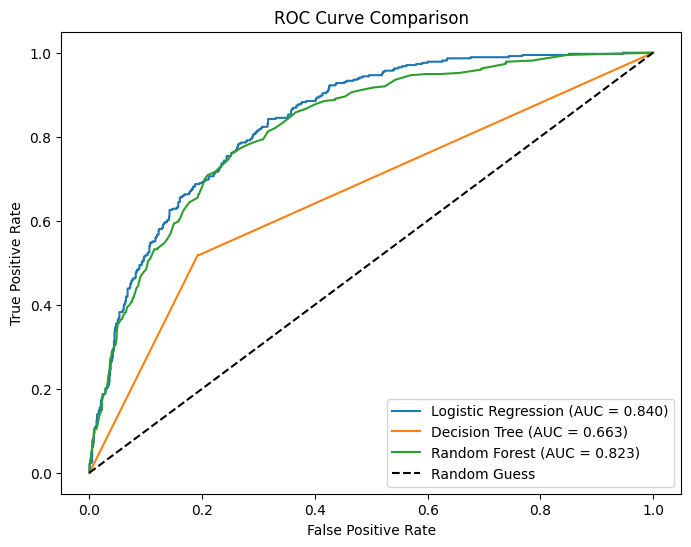

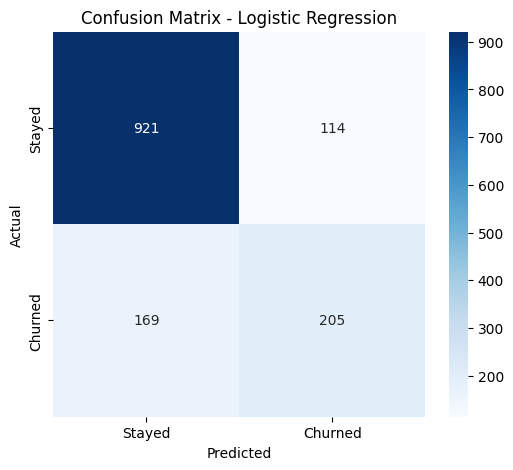

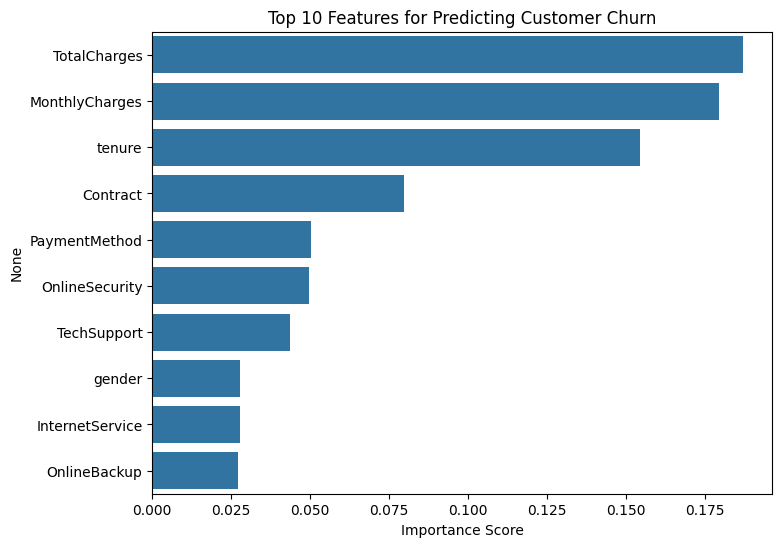


===== Full Classification Report (Best Model) =====
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [4]:
# =========================================================
# TASK 4: Customer Churn Prediction
# =========================================================
# This script does the following step by step:
# 1. Load the data
# 2. Perform feature engineering and preprocessing
# 3. Train multiple machine learning models
# 4. Compare model performance using ROC-AUC and F1-Score
# =========================================================

# ---- Step 1: Import required libraries ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

# ---- Step 2: Load the dataset ----
# NOTE: The dataset file must be uploaded to Colab first
# Kaggle file is usually named 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset shape (rows, columns):", df.shape)

print("\nColumn info:")
print(df.info())

# ---- Step 3: Drop the customer ID column (not useful for prediction) ----
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# ---- Step 4: Fix the TotalCharges column ----
# In this dataset, 'TotalCharges' is stored as text (object) but should be numeric.
# Some rows have blank spaces instead of numbers, which we need to handle.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("\nMissing values after converting TotalCharges to numeric:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill missing TotalCharges with the median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# ---- Step 5: Encode the target column ----
# Churn: Yes -> 1 (customer left), No -> 0 (customer stayed)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("\nChurn value counts (class balance):")
print(df['Churn'].value_counts())

# ---- Step 6: Encode categorical (text) columns ----
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"\nCategorical columns to encode: {categorical_cols}")

le = LabelEncoder()
df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# ---- Step 7: Separate Features (X) and Target (y) ----
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# ---- Step 8: Train/Test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining data: {X_train.shape[0]} rows")
print(f"Testing data: {X_test.shape[0]} rows")

# ---- Step 9: Feature Scaling (for Logistic Regression) ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---- Step 10: Train and compare multiple classification models ----
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = {}
roc_data = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        "Accuracy": acc, "Precision": prec, "Recall": rec,
        "F1-Score": f1, "ROC-AUC": roc_auc
    }

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, roc_auc)

    print(f"\n===== {name} =====")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1-Score : {f1:.3f}")
    print(f"ROC-AUC  : {roc_auc:.3f}")

# ---- Step 11: Compare all model results in a table ----
results_df = pd.DataFrame(results).T
print("\n===== Comparison of All Models =====")
print(results_df)

# ---- Step 12: Identify the best model (based on ROC-AUC) ----
best_model_name = results_df['ROC-AUC'].idxmax()
print(f"\nBest model (based on ROC-AUC): {best_model_name}")

best_model = models[best_model_name]
if best_model_name == "Logistic Regression":
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

# ---- Step 13: Plot ROC Curves for all models ----
plt.figure(figsize=(8, 6))
for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()
print("\n")

# ---- Step 14: Plot Confusion Matrix for the best model ----
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
print("\n")
print("\n")
# ---- Step 15: Feature Importance (using Random Forest) ----
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 10 Features for Predicting Customer Churn")
plt.xlabel("Importance Score")
plt.show()

print("\n===== Full Classification Report (Best Model) =====")
print(classification_report(y_test, y_pred_best))
